Inspired from the research papers -

* **You are in a drawdown. When should you start worrying?**
Adam Rej, Philip Seager & Jean-Philippe Bouchaud
Capital Fund Management, 23 rue de l’Université, 75007 Paris

* **Drawdown Risk Beyond Brownian Motion**
A Monte-Carlo Framework, Non-Gaussian Extensions, and Long Memory
Francesco Landolfi
Epiphany, Imperia, Italy

## What is the RSB Model?

The **RSB (Rej–Seager–Bouchaud) Model** is a quantitative framework used to determine whether a trading strategy's **drawdown is statistically normal or unusually severe** given its assumed **Sharpe ratio**. :contentReference[oaicite:0]{index=0}

It models strategy P&L as a **drifted Brownian motion**:

$$
dPnL = \mu\,dt + \sigma\,dW
$$

where the drift $\mu$ represents the strategy's Sharpe ratio after normalizing volatility. :contentReference[oaicite:1]{index=1}

The model mainly evaluates:

- **Drawdown depth** — how much the strategy falls from its peak.
- **Drawdown length** — how long the strategy remains in drawdown.

RSB provides probability distributions and **5% extreme thresholds** for these measures. If the actual drawdown exceeds these thresholds, it becomes a warning that the assumed Sharpe ratio or model may need to be reconsidered. :contentReference[oaicite:2]{index=2}

### In Simple Terms

> **RSB tells us how much and how long a strategy can normally suffer for a given Sharpe ratio, and helps identify unusually bad drawdowns.**

# **Necessary Libraries**

In [ ]:
import pandas as pd
import yfinance as yf
import numpy as np
import matplotlib.pyplot as plt

USING YF TO GET RETURNS (MADE FOR TESTING PURPOSE ONLY , RETURNS DATA CAN ALSO BE USED)

In [ ]:
ticker=yf.Ticker('AAPL')
df=ticker.history(period='1y')
df['returns']=(df['Close'].shift(-1)-df['Close'])/df['Close']
cols=['Close','returns']
data=df[cols]
data.dropna(inplace=True)
data.head()

/tmp/ipykernel_750/2663749934.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


,Close,returns
Date,,
2025-08-12 00:00:00-04:00,228.804794,0.016024
2025-08-13 00:00:00-04:00,232.471252,-0.002357
2025-08-14 00:00:00-04:00,231.923279,-0.005112
2025-08-15 00:00:00-04:00,230.737640,-0.003022
2025-08-18 00:00:00-04:00,230.040237,-0.001429


# **Using 1 year data for testing by Monte-Carlo simulations**

In [ ]:
data=pd.read_csv('/content/bad_strategy_returns.csv')
data

,date,Close,returns
0,2024-08-12,102.088631,0.020886
1,2024-08-13,101.579081,-0.004991
2,2024-08-14,101.680035,0.000994
3,2024-08-15,102.238278,0.005490
4,2024-08-16,101.331723,-0.008867
...,...,...,...
247,2025-07-23,66.436537,-0.021648
248,2025-07-24,65.956200,-0.007230
249,2025-07-25,62.919396,-0.046043
250,2025-07-28,62.352587,-0.009008


# **DATA CREATED**

as total number of trading days are 252 we kept iteration days as 252

In [ ]:
days=252
total_simulations=1000
simulations=[[0]*days]*total_simulations

last_price=data['Close'].iloc[-1]
returns=data['returns']
avg_returns=returns.mean()
volitalty=returns.std()

mu=avg_returns*np.sqrt(days)
standard_volatility=volitalty*np.sqrt(days)

sharpe=avg_returns/volitalty
anual_sharpe=sharpe*np.sqrt(252)
sharpe,avg_returns,volitalty,anual_sharpe

(np.float64(-0.08505720238735161),
 np.float64(-0.0017125042306925335),
 0.020133559329799808,
 np.float64(-1.3502412283909304))

# **MONTE CARLO - GAUSSIAN**



---
Here Gaussian Monte Carlo is used by using The Normal distribution concept with using Average Returns and Volatility


In [ ]:
last_price

np.float64(61.67331081383716)

In [ ]:
l=[]
for i in range(total_simulations):
  current_simulated_price = data['Close'].iloc[-1]
  f=[]
  for j in range(days):
    daily_random_return = np.random.normal(loc=avg_returns, scale=volitalty)
    current_simulated_price = current_simulated_price * (1 + daily_random_return)
    f.append(current_simulated_price)
  l.append(f)

Text(0.5, 1.0, 'MONTE CARLO - GAUSSIAN')

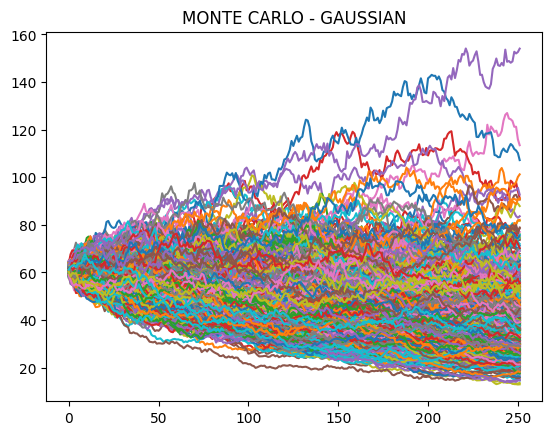

In [ ]:
for i in l:
  plt.plot(i)
plt.title('MONTE CARLO - GAUSSIAN')

In [ ]:
sharpe,avg_returns

(np.float64(-0.08505720238735161), np.float64(-0.0017125042306925335))

In [ ]:
final_prices = []

for simulation in l:
    final_prices.append(simulation[-1])

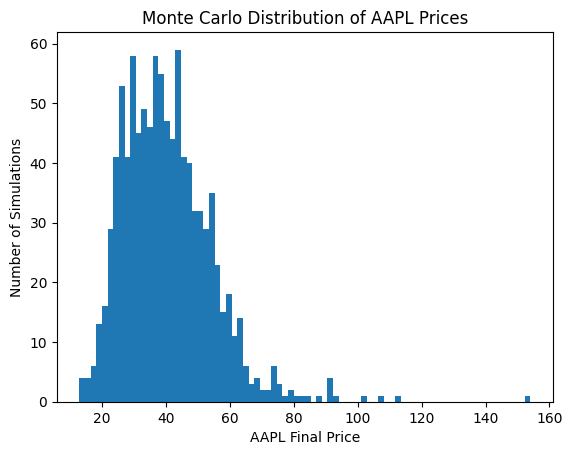

In [ ]:
plt.hist(final_prices,bins=80)
plt.xlabel("AAPL Final Price")
plt.ylabel("Number of Simulations")
plt.title("Monte Carlo Distribution of AAPL Prices")
plt.show()

In [ ]:
final_prices

[np.float64(33.87835468228355),
 np.float64(39.60076099134108),
 np.float64(44.15264003308591),
 np.float64(56.88069552932193),
 np.float64(40.65428077900468),
 np.float64(15.701224394046184),
 np.float64(22.720706718820928),
 np.float64(45.04162371967798),
 np.float64(33.48675055129103),
 np.float64(50.968957545345646),
 np.float64(25.5636779538807),
 np.float64(50.379975346392044),
 np.float64(20.001841470389714),
 np.float64(66.02750528179504),
 np.float64(43.60232993227786),
 np.float64(38.28042995131176),
 np.float64(113.42944350905377),
 np.float64(60.448404645184404),
 np.float64(60.900581912890814),
 np.float64(25.350062577003015),
 np.float64(44.28447890540481),
 np.float64(29.678841871182733),
 np.float64(32.52416064986117),
 np.float64(18.75871002357781),
 np.float64(24.07264913191367),
 np.float64(26.962398202068105),
 np.float64(34.2604848692579),
 np.float64(30.44497886329841),
 np.float64(30.485014902870713),
 np.float64(27.93893392249482),
 np.float64(23.470834010625747

# **MONTE CARLO - CHOICE**

This simulation is done by keeping the daily returns same as before so its the realistic monte carlo



In [ ]:
days=252
total_simulations=1000
simulations=[[0]*days]*total_simulations

last_price=data['Close'].iloc[-1]
returns=data['returns']
avg_returns=returns.mean()
volitalty=returns.std()

mu=avg_returns*np.sqrt(days)
standard_volatility=volitalty*np.sqrt(days)

sharpe=avg_returns/volitalty
anual_sharpe=sharpe*np.sqrt(252)
sharpe,avg_returns,volitalty,anual_sharpe


(np.float64(-0.08505720238735161),
 np.float64(-0.0017125042306925335),
 0.020133559329799808,
 np.float64(-1.3502412283909304))

In [ ]:
c=[]
for i in range(total_simulations):
  current_simulated_price = data['Close'].iloc[-1]
  f=[]
  for j in range(days):
    daily_random_return = float(np.random.choice(returns))
    current_simulated_price = current_simulated_price * (1 + daily_random_return)
    f.append(current_simulated_price)
  c.append(f)

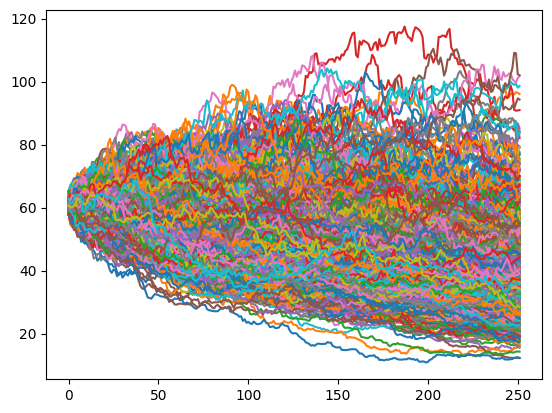

In [ ]:
for i in c:
  plt.plot(i)

In [ ]:
final_prices = []

for simulation in c:
    final_prices.append(simulation[-1])

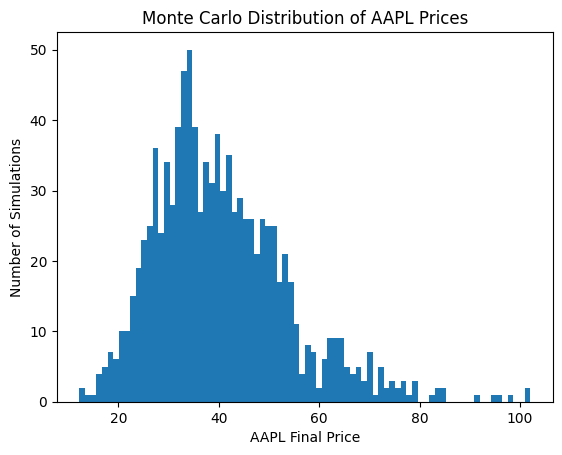

In [ ]:
plt.hist(final_prices,bins=80)
plt.xlabel("AAPL Final Price")
plt.ylabel("Number of Simulations")
plt.title("Monte Carlo Distribution of AAPL Prices")
plt.show()

# **Risk Measurement Functions**

These five functions each take a list of price paths (real or simulated) and
extract one specific risk statistic per path. All five share the same core
idea: track the running maximum price reached so far, and measure something
about how the price behaves relative to that peak.

### 1. `drawdown()` — Maximum Drawdown
For each path, tracks the running peak price at every point in time, then
measures the gap between that peak and the current price (peak − current).
The function returns the single largest gap observed across the whole path —
the worst peak-to-trough decline. This is the headline number: "how deep did
the worst losing streak get."

### 2. `max_loss()` — Maximum Loss
Measures the total swing in the path — the difference between the highest
and lowest values it ever reached. Unlike drawdown, this doesn't require the
low point to come *after* the high point in time; it's a simpler, broader
measure of how much the price moved from its best to its worst level overall.

### 3. `days_of_lower()` — Final Negative Time
Counts how many days, out of the whole path, the price spent *below* its
running peak (i.e., "underwater," not at a new high). A high value means the
strategy spent most of its life recovering or losing ground rather than
sitting at new highs.

### 4. `recovery_days()` — Longest Recovery Time
Finds the longest unbroken stretch of consecutive days spent underwater.
This captures duration specifically — not how deep the loss was, but how
long the strategy was stuck below its peak before it either recovered or the
path ended.

### 5. `last_neg()` — Last Negative Streak
Tracks a running cumulative sum of daily returns and records the last point
in the path where that running sum was negative. This captures how recently
(and for how long, near the end) the strategy was in a losing streak —
useful for understanding whether the pain is old news or still ongoing as of
the most recent data.

---

### Why Five Separate Measures Instead of One
A strategy can look fine on one measure and concerning on another — e.g., a
shallow but very long-lasting drawdown, or a deep but quickly-recovered one.
Using all five together (rather than relying on drawdown alone) gives a
fuller picture of *how* a strategy is behaving abnormally, not just *whether*
it is.

In [ ]:
gauss=l
choice=c

# **DRAWDOWN CALCULATOR**

In [ ]:
def drawdown(l):
  s=[]
  subs=[]

  for i in l:
    f=[]
    diff=[]
    maxi=0
    for j in range(len(i)):
      if j==0:
        maxi=i[j]
        dd=maxi-(i[j])
        f.append(dd)
      elif i[j]>=maxi:
        maxi=i[j]
        dd=maxi-(i[j])
        f.append(dd)
      elif i[j]<maxi:
        dd=maxi-(i[j])

        f.append(dd)
    s.append(max(f))
  return s

In [ ]:
gaussian_drawdown=drawdown(gauss)
real_drawdown=drawdown(choice)

In [ ]:
gaussian_drawdown

[np.float64(30.512826488793046),
 np.float64(30.706838861635447),
 np.float64(21.81229473422419),
 np.float64(19.40036192853966),
 np.float64(24.33924087206225),
 np.float64(45.42541825415986),
 np.float64(46.74329667408694),
 np.float64(23.03342026061349),
 np.float64(36.1936439680407),
 np.float64(25.147681586427574),
 np.float64(38.83429583014735),
 np.float64(23.043090915404278),
 np.float64(43.180592868607434),
 np.float64(34.67786834801479),
 np.float64(24.85667324087558),
 np.float64(29.809399670867784),
 np.float64(14.791536158633555),
 np.float64(20.899075403996008),
 np.float64(25.576104010671273),
 np.float64(49.54685736740471),
 np.float64(30.312999372314813),
 np.float64(33.526576676675596),
 np.float64(35.78815248405716),
 np.float64(45.206333005350174),
 np.float64(38.36644553191898),
 np.float64(35.444230311539286),
 np.float64(50.01032057838712),
 np.float64(32.02866080536838),
 np.float64(36.48483118103606),
 np.float64(35.99166645301225),
 np.float64(42.7719567388566

# **MAX LOSS AFTER PEAK**

In [ ]:
def max_loss(gauss):
  maxi=[]

  for i in gauss:
    series=pd.Series(i)
    returns=series.shift(-1)-(series)
    returns = returns.dropna()

    sums=[]
    sum=0
    for i in returns:
      sum+=i
      sums.append(sum)
    maxi.append(max(0, -min(sums)))

  return maxi

In [ ]:
gauss_loss=max_loss(gauss)
real_loss=max_loss(choice)

In [ ]:
gauss_loss

[30.512826488793046,
 23.850406161265667,
 21.809226231467484,
 9.078480044467014,
 21.486398921296797,
 44.97234824822214,
 41.38859820789564,
 19.7080253595377,
 34.05665113795553,
 15.19057874535683,
 38.83429583014734,
 22.17078676270785,
 40.671553653138155,
 0,
 19.60878369375709,
 24.76686297056665,
 2.0354899277631873,
 12.546136452960383,
 14.998682336202315,
 38.849835277150284,
 25.12184068947343,
 32.300973805871074,
 28.95690326825691,
 43.293252771906495,
 37.13402058103816,
 35.444230311539286,
 28.93838569091203,
 32.02866080536838,
 33.728176438719075,
 33.242556942112046,
 40.97076565276751,
 28.575627180848983,
 24.452462145269592,
 29.76958647721181,
 39.04252105973765,
 7.036820849041462,
 13.498828727822563,
 43.04008899722003,
 40.82333957599822,
 13.098916579874185,
 34.714944094452605,
 24.26228454237051,
 41.73892363574126,
 29.812882669354366,
 35.27288297764045,
 16.999461706879174,
 30.1941521810558,
 27.895653470163936,
 21.147713225453117,
 32.15342477310

# **DAYS AFTER PEAK**

In [ ]:
def days_of_lower(l):

  count=[]
  for i in l:
    maxi=0
    c=0
    for j in range(len(i)):

      if i[j]>=maxi:
        maxi=i[j]

      elif i[j]<maxi:
        c+=1


    count.append(c)

  return count

In [ ]:
gauss_days=days_of_lower(gauss)
real_days=days_of_lower(choice)

In [ ]:
len(gauss_days)

1000

# **RECOVERY**

In [ ]:
def recovery_days(l):
  count = []

  for i in l:
      maxi = 0
      c = 0
      f = []

      for j in range(len(i)):

          if i[j] >= maxi:
              maxi = i[j]
              f.append(c)
              c = 0

          elif i[j] < maxi:
              c += 1
      f.append(c)
      count.append(max(f))

  return count

In [ ]:
gauss_recovery=recovery_days(gauss)
real_recovery=recovery_days(choice)

In [ ]:
len(real_recovery)

1000

# **LAST NEGATIVE**

In [ ]:
def last_neg(gauss):

  neg=[]
  for i in gauss:
    series=pd.Series(i)
    returns=series.shift(-1)-series
    returns = returns.dropna()

    sum=0
    ind=[]
    for j in range(len(returns)):
      sum+=returns[j]
      if sum<0:
        ind.append(j)

    if not ind:
      neg.append(0)
    else:
       neg.append(ind[-1])
    return neg

In [ ]:
real_neg=last_neg(choice)
gauss_neg=last_neg(gauss)

# **DISTRIBUTIONS**



DRAWDOWN

Text(0.5, 1.0, 'drawdown distribution')

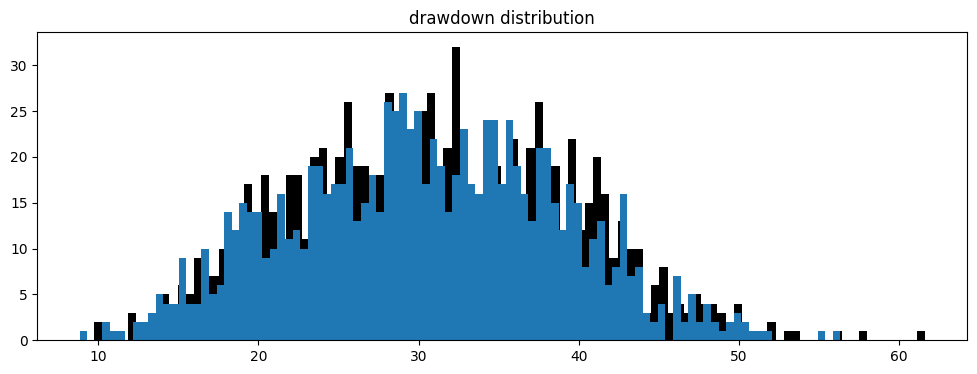

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(gaussian_drawdown,bins=100,color='black')
plt.hist(real_drawdown,bins=100)
plt.title('drawdown distribution')

### 1. Drawdown — Gaussian vs Real

| Statistic     | Gaussian Simulation       | Real Data                      |
| ------------- | ------------------------- | ------------------------------ |
| Distribution  | Approximately bell-shaped | Similar but more irregular     |
| Central Range | ~25–40%                   | ~20–40%                        |
| Minimum       | ~9%                       | ~10%                           |
| Maximum       | ~62%                      | ~51%                           |
| Overall Shape | More smooth/symmetric     | More noisy                     |
| Conclusion    | Reasonable approximation  | Shows more empirical variation |

LOSS

Text(0.5, 1.0, 'gauss loss distribution')

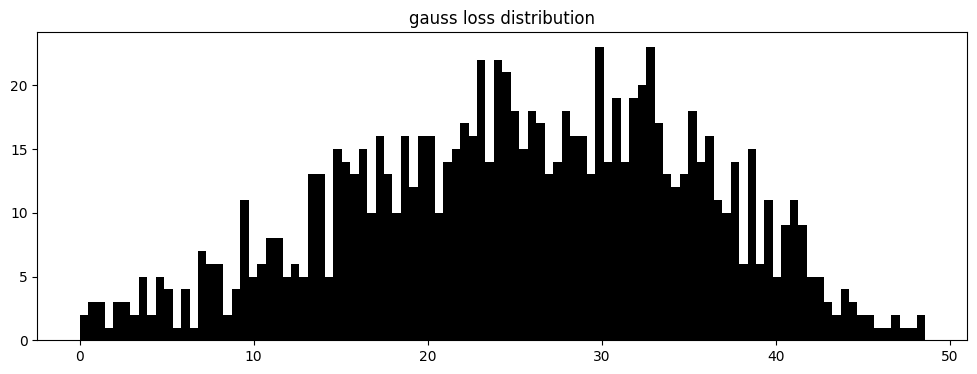

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(gauss_loss,bins=100,color='black')
plt.title('gauss loss distribution')

Text(0.5, 1.0, 'real loss distribution')

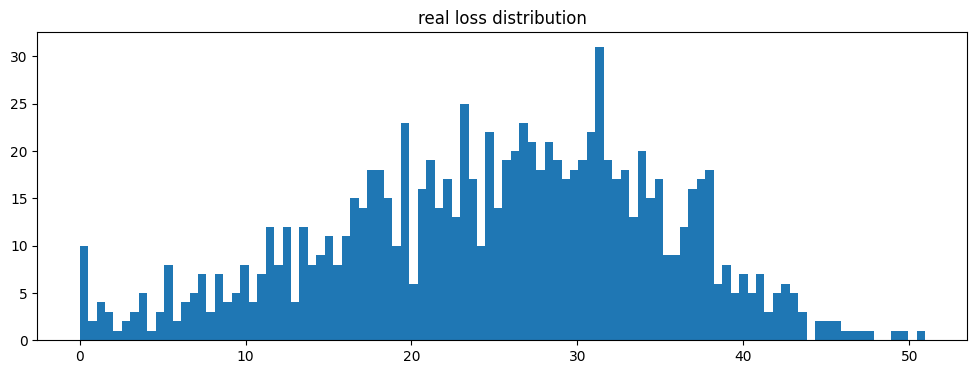

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(real_loss,bins=100)
plt.title('real loss distribution')

### 2. Loss — Gaussian vs Real

| Statistic     | Gaussian Simulation     | Real Data               |
| ------------- | ----------------------- | ----------------------- |
| Distribution  | Approximately symmetric | Similar overall shape   |
| Central Range | ~20–40%                 | ~20–40%                 |
| Minimum       | ~0                      | ~0                      |
| Maximum       | ~50%                    | ~51%                    |
| Peak          | ~30–33%                 | ~30–32%                 |
| Conclusion    | Good approximation      | Slightly more irregular |


RECOVERY

Text(0.5, 1.0, 'gauss recovery distribution')

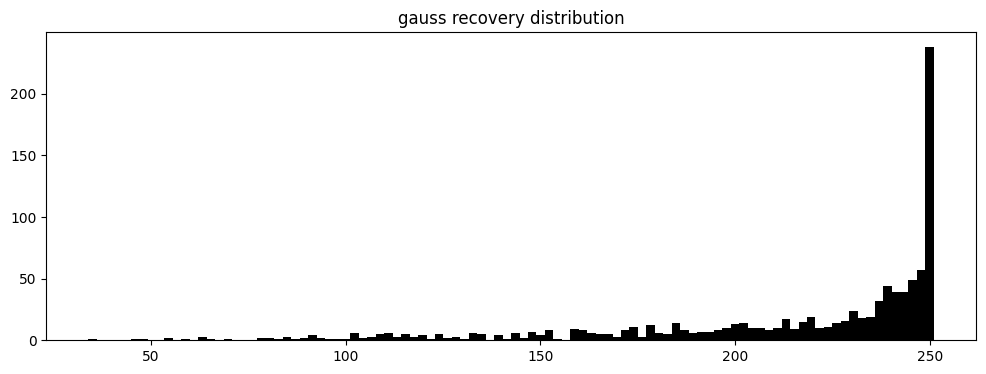

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(gauss_recovery,bins=100,color='black')
plt.title('gauss recovery distribution')

Text(0.5, 1.0, 'real recovery distribution')

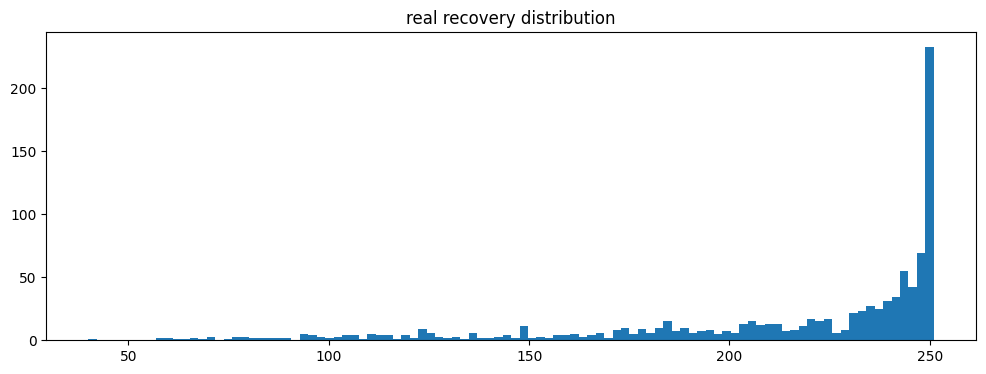

In [ ]:

plt.figure(figsize=(12,4))
plt.hist(real_recovery,bins=100)
plt.title('real recovery distribution')

### 3. Recovery — Gaussian vs Real

| Statistic          | Gaussian Simulation   | Real Data              |
| ------------------ | --------------------- | ---------------------- |
| Distribution       | Strongly left-skewed  | Strongly left-skewed   |
| Main Concentration | ~240–250 days         | ~240–250 days          |
| Peak               | ~250 days             | ~250 days              |
| Lower Tail         | Extends to ~30 days   | Extends to ~35–40 days |
| Shape              | Very similar          | Very similar           |
| Conclusion         | **Very strong match** | **Very strong match**  |


LOWER PEAK DAYS

Text(0.5, 1.0, 'gauss days distribution')

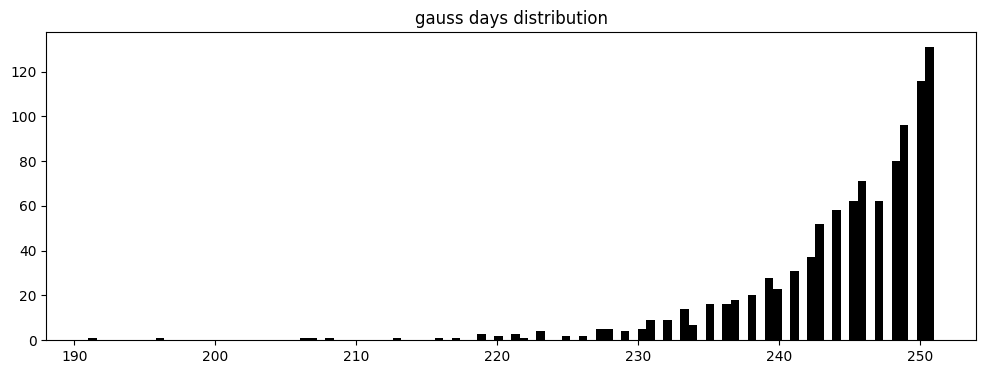

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(gauss_days,bins=100,color='black')
plt.title('gauss days distribution')

Text(0.5, 1.0, 'real days distribution')

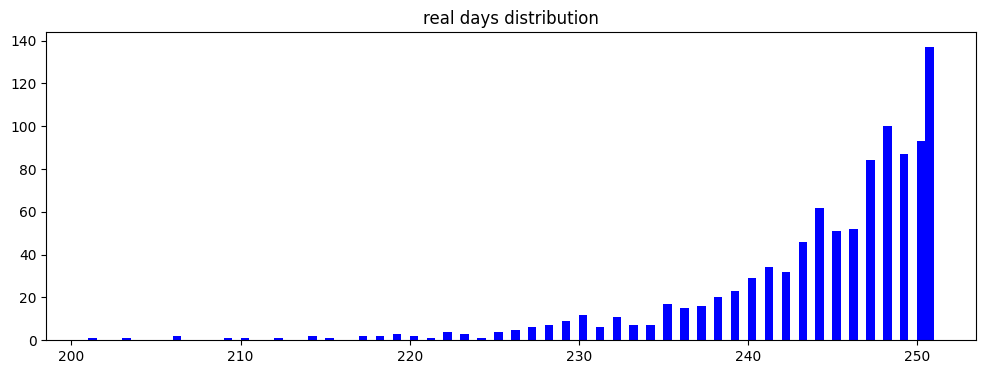

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(real_days,bins=100,color='blue')
plt.title('real days distribution')


### 4. Lower Peak Days — Gaussian vs Real

| Statistic    | Gaussian Simulation            | Real Data                      |
| ------------ | ------------------------------ | ------------------------------ |
| Distribution | Strongly concentrated near 250 | Strongly concentrated near 250 |
| Main Range   | ~235–251 days                  | ~235–251 days                  |
| Peak         | ~250 days                      | ~251 days                      |
| Lower Tail   | Extends to ~190 days           | Extends to ~200 days           |
| Shape        | Highly right-concentrated      | Highly right-concentrated      |
| Conclusion   | **Very strong match**          | **Very strong match**

NEGATIVE

Text(0.5, 1.0, 'gauss neg distribution')

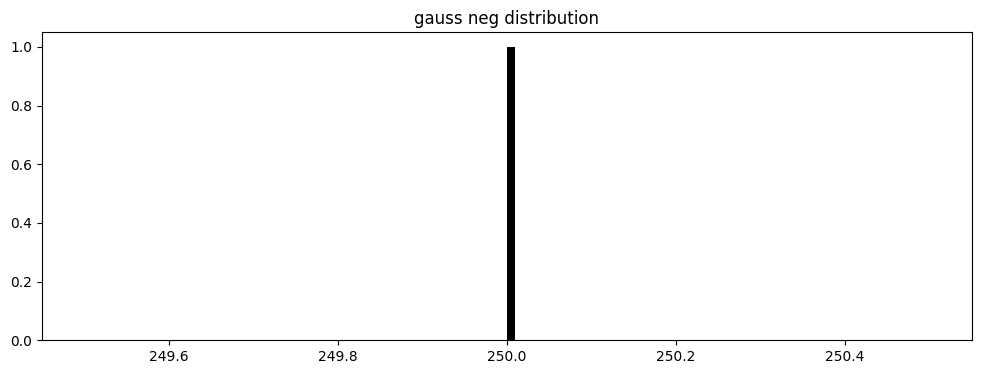

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(gauss_neg,bins=100,color='black')
plt.title('gauss neg distribution')

Text(0.5, 1.0, 'real neg distribution')

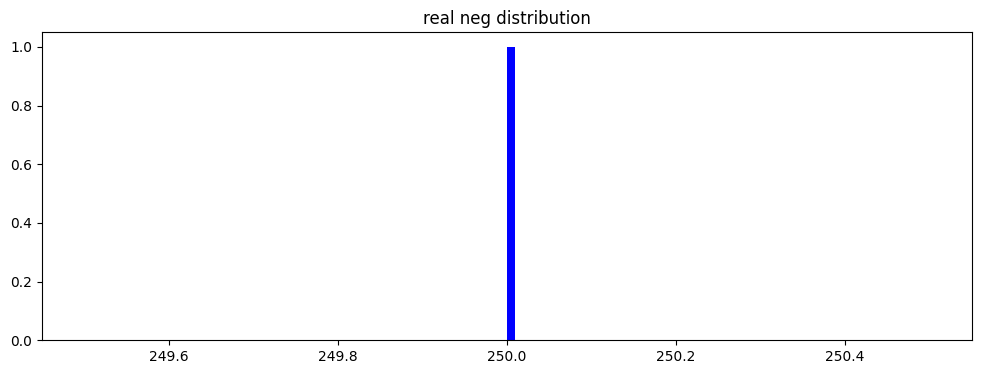

In [ ]:
plt.figure(figsize=(12,4))
plt.hist(real_neg,bins=100,color='blue')
plt.title('real neg distribution')

### 5. Negative — Gaussian vs Real

| Statistic    | Gaussian Simulation                 | Real Data                           |
| ------------ | ----------------------------------- | ----------------------------------- |
| Distribution | Almost entirely concentrated at 250 | Almost entirely concentrated at 250 |
| Main Value   | ~250 days                           | ~250 days                           |
| Dispersion   | Almost none                         | Almost none                         |
| Shape        | Single sharp peak                   | Single sharp peak                   |
| Conclusion   | **Nearly identical**                | **Nearly identical**                |




###  Overall Comparison

| Metric              | Similarity          | Observation                                                         |
| ------------------- | ------------------- | ------------------------------------------------------------------- |
| **Drawdown**        | 🟢 Good             | Similar range and central tendency, but real data is more irregular |
| **Loss**            | 🟢 Good             | Similar distribution and range                                      |
| **Recovery**        | 🟢 Very Strong      | Both heavily concentrated near 250 days                             |
| **Lower Peak Days** | 🟢 Very Strong      | Both show strong concentration near 250 days                        |
| **Negative**        | 🟢 Nearly Identical | Both are concentrated around 250 days                               |

**Overall:** The Gaussian Monte Carlo simulation captures the major characteristics of the real strategy reasonably well, with the **strongest agreement in Recovery and Lower Peak Days**. The main differences appear in **Drawdown and Loss**, where the real data exhibits greater irregularity and potentially non-Gaussian behavior.


# **PERCENTILE CALCULATION**

In [ ]:
features=[gaussian_drawdown,real_drawdown,gauss_days,real_days,gauss_recovery,real_recovery,gauss_loss,real_loss,gauss_neg,real_neg]

percentiles=[]
for i in features:
  print(np.percentile(i,[50,90,95]))
  percentiles.append(np.percentile(i,[50,90,95]))

[30.79833392 41.84172537 44.61383209]
[30.42478262 41.27559952 43.5909785 ]
[246. 251. 251.]
[247. 251. 251.]
[235. 251. 251.]
[236. 251. 251.]
[25.76395445 38.15808206 40.93698157]
[26.03652658 37.46757815 40.001582  ]
[250. 250. 250.]
[250. 250. 250.]


In [ ]:
features=['gaussian_drawdown','real_drawdown','gauss_days','real_days','gauss_recovery','real_recovery','gauss_loss','real_loss','gauss_neg','real_neg']

In [ ]:
data=pd.DataFrame(percentiles,columns=['50th','90th','95th'],index=features)

In [ ]:
data

,50th,90th,95th
gaussian_drawdown,30.798334,41.841725,44.613832
real_drawdown,30.424783,41.275600,43.590979
gauss_days,246.000000,251.000000,251.000000
real_days,247.000000,251.000000,251.000000
gauss_recovery,235.000000,251.000000,251.000000
real_recovery,236.000000,251.000000,251.000000
gauss_loss,25.763954,38.158082,40.936982
real_loss,26.036527,37.467578,40.001582
gauss_neg,250.000000,250.000000,250.000000
real_neg,250.000000,250.000000,250.000000


WITH RESPECT TO RETURNS MADE FROM NORMAL SHIFT FEATURES , ONLY USED FOR TESTING

In [ ]:
ticker=yf.Ticker('AAPL')
df=ticker.history(period='1y')
df['returns']=(df['Close'].shift(-1)-df['Close'])/df['Close']
cols=['Close','returns']
data=df[cols]
data.dropna(inplace=True)
data.head()


/tmp/ipykernel_750/4120114445.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


,Close,returns
Date,,
2025-08-12 00:00:00-04:00,228.804810,0.016024
2025-08-13 00:00:00-04:00,232.471252,-0.002357
2025-08-14 00:00:00-04:00,231.923279,-0.005112
2025-08-15 00:00:00-04:00,230.737656,-0.003023
2025-08-18 00:00:00-04:00,230.040237,-0.001429


CREATING FEATURE PERCENTILES OF REAL DATA

In [ ]:
data=pd.read_csv('/content/bad_strategy_returns.csv')
data

days=252
total_simulations=1000
simulations=[[0]*days]*total_simulations

last_price=data['Close'].iloc[-1]
returns=data['returns']
avg_returns=returns.mean()
volitalty=returns.std()

mu=avg_returns*np.sqrt(days)
standard_volatility=volitalty*np.sqrt(days)

sharpe=avg_returns/volitalty
anual_sharpe=sharpe*np.sqrt(252)
sharpe,avg_returns,volitalty,anual_sharpe

(np.float64(-0.08505720238735161),
 np.float64(-0.0017125042306925335),
 0.020133559329799808,
 np.float64(-1.3502412283909304))

In [ ]:
asset_drawdown=drawdown([data['Close']])
print(asset_drawdown)
asset_loss=max_loss([data['Close']])
print(asset_loss)
asset_days=days_of_lower([data['Close']])
print(asset_days)
asset_recovery=recovery_days([data['Close']])
print(asset_recovery)
asset_neg=last_neg([data['Close']])
print(asset_neg)

[np.float64(53.531799056188945)]
[40.41532003072328]
[235]
[122]
[250]


In [ ]:
from scipy.stats import percentileofscore

# Gaussian MC
gauss_drawdown_percentile = percentileofscore(gaussian_drawdown, asset_drawdown)
gauss_loss_percentile = percentileofscore(gauss_loss, asset_loss)
gauss_days_percentile = percentileofscore(gauss_days, asset_days)
gauss_recovery_percentile = percentileofscore(gauss_recovery, asset_recovery)
gauss_neg_percentile = percentileofscore(gauss_neg, asset_neg)

# Realistic MC
real_drawdown_percentile = percentileofscore(real_drawdown, asset_drawdown)
real_loss_percentile = percentileofscore(real_loss, asset_loss)
real_days_percentile = percentileofscore(real_days, asset_days)
real_recovery_percentile = percentileofscore(real_recovery, asset_recovery)
real_neg_percentile = percentileofscore(real_neg, asset_neg)

# Combined table
final_1yr = pd.DataFrame({
    "Gaussian MC": [gauss_drawdown_percentile, gauss_loss_percentile, gauss_days_percentile, gauss_recovery_percentile, gauss_neg_percentile],
    "Realistic MC": [real_drawdown_percentile, real_loss_percentile, real_days_percentile, real_recovery_percentile, real_neg_percentile]
}, index=["Drawdown", "Max Loss", "Days Lower", "Recovery", "Final Negative"])



## Strategy Validation Rules

| Percentile Range | Health Status | Interpretation |
|---|---|---|
| **< 50th percentile** | 🟢 **Healthy** | Strategy is performing better than most Monte Carlo outcomes |
| **50th–90th percentile** | 🟡 **Normal** | Strategy is within the expected range |
| **90th–95th percentile** | 🟠 **Borderline** | Strategy is deteriorating and showing elevated risk |
| **> 95th percentile** | 🔴 **Breaking** | Strategy is performing significantly worse than expected and may be unstable |

### Overall Classification Rule

- **< 50th percentile** → 🟢 **Healthy**
- **50th–90th percentile** → 🟡 **Normal**
- **90th–95th percentile** → 🟠 **Borderline**
- **> 95th percentile** → 🔴 **Breaking**

> **If any critical risk metric exceeds the 95th percentile, the overall strategy is classified as 🔴 Breaking.**

### Interpretation

The percentile represents how extreme the strategy's observed outcome is compared with the outcomes generated by the Monte Carlo simulations.

- **30th percentile** → 🟢 Healthy
- **70th percentile** → 🟡 Normal
- **93rd percentile** → 🟠 Borderline
- **99th percentile** → 🔴 Breaking

In [ ]:
final_1yr

,Gaussian MC,Realistic MC
Drawdown,[99.7],[99.80000000000001]
Max Loss,[93.9],[95.30000000000001]
Days Lower,[9.15],[11.100000000000001]
Recovery,[6.9],[7.6000000000000005]
Final Negative,[100.0],[100.0]


In [ ]:
data=pd.DataFrame(percentiles,columns=['50th','90th','95th'],index=features)
data

,50th,90th,95th
gaussian_drawdown,30.798334,41.841725,44.613832
real_drawdown,30.424783,41.275600,43.590979
gauss_days,246.000000,251.000000,251.000000
real_days,247.000000,251.000000,251.000000
gauss_recovery,235.000000,251.000000,251.000000
real_recovery,236.000000,251.000000,251.000000
gauss_loss,25.763954,38.158082,40.936982
real_loss,26.036527,37.467578,40.001582
gauss_neg,250.000000,250.000000,250.000000
real_neg,250.000000,250.000000,250.000000


## Strategy Validation — Observations

Based on the Monte Carlo validation results, the following observations can be made:

### 1. Drawdown — Critical Concern 🔴

* The strategy's drawdown lies at the **99.7th percentile** under Gaussian MC.
* Under Realistic MC, it lies at the **99.8th percentile**.
* Both values are **far above the 95th-percentile breaking threshold**.
* This indicates that the strategy experiences substantially higher drawdown than almost all simulated outcomes.

**Observation:** The strategy's drawdown behavior is **extremely poor and falls into the Breaking category**.

---

### 2. Maximum Loss — Borderline to Breaking 🟠🔴

* Maximum Loss is at the **93.9th percentile** under Gaussian MC.
* Under Realistic MC, it reaches the **95.3rd percentile**.
* Gaussian MC places it in the **Borderline** region.
* Realistic MC places it slightly above the **Breaking threshold**.

**Observation:** Maximum loss is unusually high and indicates **significant deterioration in downside risk**.

---

### 3. Days Lower — Healthy 🟢

* Days Lower is at the **9.15th percentile** under Gaussian MC.
* Under Realistic MC, it is at the **11.1th percentile**.
* Both are well below the 50th-percentile threshold.

**Observation:** The strategy does **not remain below its reference level unusually often**. Its duration of weakness is actually better than most simulated outcomes.

---

### 4. Recovery — Healthy 🟢

* Recovery is at the **6.9th percentile** under Gaussian MC.
* Under Realistic MC, it is at the **7.6th percentile**.
* Both are comfortably within the Healthy region.

**Observation:** The strategy's recovery behavior is **better than most simulated outcomes**.

---

### 5. Final Negative — Critical Concern 🔴

* Final Negative is at the **100th percentile** under both Gaussian and Realistic MC.
* This places the metric at the extreme end of the distribution.

**Observation:** The strategy finishes in an extremely unfavorable state relative to the simulated outcomes, making this a **major warning signal**.

---

## Overall Observation

The Monte Carlo validation reveals a **mixed risk profile**:

| Metric             | Gaussian MC | Realistic MC | Observation                    |
| ------------------ | ----------: | -----------: | ------------------------------ |
| **Drawdown**       |      99.7th |       99.8th | 🔴 **Breaking**                |
| **Max Loss**       |      93.9th |       95.3rd | 🟠🔴 **Borderline / Breaking** |
| **Days Lower**     |      9.15th |       11.1th | 🟢 **Healthy**                 |
| **Recovery**       |       6.9th |        7.6th | 🟢 **Healthy**                 |
| **Final Negative** |       100th |        100th | 🔴 **Breaking**                |

### Final Conclusion

The strategy demonstrates **good recovery characteristics and does not spend unusually long periods below its reference level**. However, these positive characteristics are outweighed by the **extremely high drawdown, elevated maximum loss, and 100th-percentile Final Negative result**.

The most significant observation is that **Drawdown is consistently above the 95th percentile in both Monte Carlo models**, reaching approximately the **99.7th–99.8th percentile**.

Therefore, according to the defined validation framework:

> **The strategy is classified as 🔴 BREAKING.**

The strategy's primary weakness is **not the duration of its losses or its ability to recover, but the extreme magnitude of its downside risk**.


# **RSB MONTE CARLO VALIDATION**
Using the theoretical function of RSB validation

RSB states you need 2 things to identify



1.   RSB Depth
2.   RSB Length



In [ ]:
rsb_depth=1.50/anual_sharpe
rsb_length=2.14 / (anual_sharpe ** 2)

rsb_depth,rsb_length

(np.float64(-1.1109126046962259), np.float64(1.1737917265262752))

OPTIONAL ONLY TO BE USED WHEN USING THIS ELSE SKIP THIS

In [ ]:
ticker=yf.Ticker('AAPL')
df=ticker.history(period='10y')
df['returns']=(df['Close'].shift(-1)-df['Close'])/df['Close']
cols=['Close','returns']
data=df[cols]
data.dropna(inplace=True)
data.head()

/tmp/ipykernel_750/2858926573.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data.dropna(inplace=True)


,Close,returns
Date,,
2016-08-12 00:00:00-04:00,24.739212,0.012017
2016-08-15 00:00:00-04:00,25.036507,-0.000913
2016-08-16 00:00:00-04:00,25.013638,-0.001463
2016-08-17 00:00:00-04:00,24.977043,-0.001282
2016-08-18 00:00:00-04:00,24.945023,0.002567


RUN THIS 10 YEAR DATASET

In [ ]:
data=pd.read_csv('/content/bad_strategy_returns_10y.csv')
data

,date,Close,returns
0,2016-08-12,102.088631,0.020886
1,2016-08-15,101.579081,-0.004991
2,2016-08-16,101.680035,0.000994
3,2016-08-17,102.238278,0.005490
4,2016-08-18,101.331723,-0.008867
...,...,...,...
2515,2026-04-03,0.932218,0.023747
2516,2026-04-06,0.945244,0.013973
2517,2026-04-07,0.988824,0.046104
2518,2026-04-08,0.999301,0.010595


In [ ]:
days=2520
total_simulations=1000
simulations=[[0]*days]*total_simulations

last_price=data['Close'].iloc[-1]
returns=data['returns']
avg_returns=returns.mean()
volitalty=returns.std()

mu=avg_returns*np.sqrt(days)
standard_volatility=volitalty*np.sqrt(days)

sharpe=avg_returns/volitalty
anual_sharpe=sharpe*np.sqrt(252)
sharpe,avg_returns,volitalty,anual_sharpe

(np.float64(-0.07484486733242113),
 np.float64(-0.0016028486825707992),
 0.021415612582380526,
 np.float64(-1.1881254352272512))

In [ ]:
asset_drawdown=drawdown([data['Close']])
print(asset_drawdown)
asset_loss=max_loss([data['Close']])
print(asset_loss)
asset_days=days_of_lower([data['Close']])
print(asset_days)
asset_recovery=recovery_days([data['Close']])
print(asset_recovery)
asset_neg=last_neg([data['Close']])
print(asset_neg)

[np.float64(165.56931505312068)]
[101.2550011611539]
[2468]
[1019]
[2518]


NORMALIZING THE OUTPUT FOR RSB

In [ ]:
normalized_drawdown=asset_drawdown/(last_price * volitalty * np.sqrt(252))
normalized_loss=asset_loss/(last_price * volitalty * np.sqrt(252))
normalized_days=asset_days
normalized_recovery=asset_recovery
normalized_neg=asset_neg

In [ ]:
# RSB Monte Carlo

rsb = []

days = 2520
total_simulations = 1000

rsb_daily_drift = anual_sharpe / 252
rsb_daily_volatility = 1 / np.sqrt(252)

for i in range(total_simulations):

    current_pnl = 0
    f = []

    for j in range(days):

        daily_random_return = np.random.normal(
            loc=rsb_daily_drift,
            scale=rsb_daily_volatility
        )

        current_pnl += daily_random_return
        f.append(current_pnl)

    rsb.append(f)


# Apply the five functions

rsb_drawdown = drawdown(rsb)

rsb_max_loss = max_loss(rsb)

rsb_days = days_of_lower(rsb)

rsb_recovery = recovery_days(rsb)

rsb_neg = last_neg(rsb)

In [ ]:
# ============================================================
# NORMALISED GAUSSIAN MC
# ============================================================

days = 2520
total_simulations = 1000

gauss_norm = []

for i in range(total_simulations):

    f = []
    pnl = 0

    for j in range(days):

        # Gaussian daily return
        daily_return = np.random.normal(
            loc=avg_returns,
            scale=volitalty
        )

        # Convert to RSB units:
        # annualised volatility = volatility * sqrt(252)
        normalized_return = (
            daily_return /
            (volitalty * np.sqrt(252))
        )

        pnl += normalized_return
        f.append(pnl)

    gauss_norm.append(f)

In [ ]:
# ============================================================
# NORMALISED REALISTIC MC
# ============================================================

real_norm = []

for i in range(total_simulations):

    f = []
    pnl = 0

    for j in range(days):

        # Bootstrap an actual historical return
        daily_return = float(np.random.choice(returns))

        # Convert to RSB units
        normalized_return = (
            daily_return /
            (volitalty * np.sqrt(252))
        )

        pnl += normalized_return
        f.append(pnl)

    real_norm.append(f)

In [ ]:
# ============================================================
# APPLY THE FIVE RISK FUNCTIONS
# ============================================================

gauss_norm_drawdown = drawdown(gauss_norm)
gauss_norm_loss = max_loss(gauss_norm)
gauss_norm_days = days_of_lower(gauss_norm)
gauss_norm_recovery = recovery_days(gauss_norm)
gauss_norm_neg = last_neg(gauss_norm)


real_norm_drawdown = drawdown(real_norm)
real_norm_loss = max_loss(real_norm)
real_norm_days = days_of_lower(real_norm)
real_norm_recovery = recovery_days(real_norm)
real_norm_neg = last_neg(real_norm)

In [ ]:
from scipy.stats import percentileofscore

# ---------- RSB MC ----------
rsb_drawdown_percentile = percentileofscore(rsb_drawdown, normalized_drawdown)
rsb_loss_percentile = percentileofscore(rsb_max_loss, normalized_loss)
rsb_days_percentile = percentileofscore(rsb_days, normalized_days)
rsb_recovery_percentile = percentileofscore(rsb_recovery, normalized_recovery)
rsb_neg_percentile = percentileofscore(rsb_neg, normalized_neg)

# ---------- Gaussian MC ----------
gauss_drawdown_percentile = percentileofscore(gauss_norm_drawdown, normalized_drawdown)
gauss_loss_percentile = percentileofscore(gauss_norm_loss, normalized_loss)
gauss_days_percentile = percentileofscore(gauss_norm_days, normalized_days)
gauss_recovery_percentile = percentileofscore(gauss_norm_recovery, normalized_recovery)
gauss_neg_percentile = percentileofscore(gauss_norm_neg, normalized_neg)

# ---------- Realistic MC ----------
real_drawdown_percentile = percentileofscore(real_norm_drawdown, normalized_drawdown)
real_loss_percentile = percentileofscore(real_norm_loss, normalized_loss)
real_days_percentile = percentileofscore(real_norm_days, normalized_days)
real_recovery_percentile = percentileofscore(real_norm_recovery, normalized_recovery)
real_neg_percentile = percentileofscore(real_norm_neg, normalized_neg)

# ---------- Combined table ----------
final_10yr = pd.DataFrame({
    "RSB MC": [rsb_drawdown_percentile, rsb_loss_percentile, rsb_days_percentile, rsb_recovery_percentile, rsb_neg_percentile],
    "Gaussian MC": [gauss_drawdown_percentile, gauss_loss_percentile, gauss_days_percentile, gauss_recovery_percentile, gauss_neg_percentile],
    "Realistic MC": [real_drawdown_percentile, real_loss_percentile, real_days_percentile, real_recovery_percentile, real_neg_percentile]
}, index=["Drawdown", "Max Loss", "Days Lower", "Recovery", "Final Negative"])


In [ ]:
features = ["Drawdown", "Max Loss", "Days Lower", "Recovery", "Final Negative"]

rsb_data = [rsb_drawdown, rsb_max_loss, rsb_days, rsb_recovery, rsb_neg]
gauss_data = [gauss_norm_drawdown, gauss_norm_loss, gauss_norm_days, gauss_norm_recovery, gauss_norm_neg]
real_data = [real_norm_drawdown, real_norm_loss, real_norm_days, real_norm_recovery, real_norm_neg]

comparison = pd.DataFrame({
    ("RSB MC", "50th"): [np.percentile(x, 50) for x in rsb_data],
    ("RSB MC", "90th"): [np.percentile(x, 90) for x in rsb_data],
    ("RSB MC", "95th"): [np.percentile(x, 95) for x in rsb_data],

    ("Gaussian MC", "50th"): [np.percentile(x, 50) for x in gauss_data],
    ("Gaussian MC", "90th"): [np.percentile(x, 90) for x in gauss_data],
    ("Gaussian MC", "95th"): [np.percentile(x, 95) for x in gauss_data],

    ("Realistic MC", "50th"): [np.percentile(x, 50) for x in real_data],
    ("Realistic MC", "90th"): [np.percentile(x, 90) for x in real_data],
    ("Realistic MC", "95th"): [np.percentile(x, 95) for x in real_data],
}, index=features)


In [ ]:
comparison

RSB MC                            Gaussian MC  \
                       50th         90th         95th         50th   
Drawdown          12.598772    16.439807    17.638624    12.601044   
Max Loss          12.308199    16.186042    17.483245    12.205813   
Days Lower      2515.000000  2520.000000  2520.000000  2514.000000   
Recovery        2494.000000  2520.000000  2520.000000  2489.000000   
Final Negative  2518.000000  2518.000000  2518.000000  2518.000000   

                                         Realistic MC               \
                       90th         95th         50th         90th   
Drawdown          16.512562    17.661305    12.620534    16.401971   
Max Loss          16.240620    17.296987    12.257172    16.201170   
Days Lower      2520.000000  2520.000000  2513.000000  2519.000000   
Recovery        2520.000000  2520.000000  2490.000000  2519.000000   
Final Negative  2518.000000  2518.000000  2518.000000  2518.000000   

                             
                       95th  
Drawdown          17.401341  
Max Loss          17.210478  
Days Lower      2520.000000  
Recovery        2520.000000  
Final Negative  2518.000000

In [ ]:
final_10yr

,RSB MC,Gaussian MC,Realistic MC
Drawdown,[100.0],[100.0],[100.0]
Max Loss,[100.0],[100.0],[100.0]
Days Lower,[0.2],[0.1],[0.30000000000000004]
Recovery,[0.0],[0.0],[0.0]
Final Negative,[100.0],[100.0],[100.0]


## Strategy Validation — Final Conclusion

### Comparison

The RSB MC, Gaussian MC, and Realistic MC produce **very similar risk distributions**:

- **Drawdown:** All three models are closely aligned around the 50th, 90th, and 95th percentiles.
- **Max Loss:** All three models again show very similar values across the distribution.
- **Days Lower:** The models are broadly consistent.
- **Recovery:** The models show similar behavior, with recovery concentrated near the end of the 10-year horizon.
- **Final Negative:** All three models give the same result.

### 10-Year Strategy Result

The actual strategy lies at the **100th percentile for both Drawdown and Max Loss across all three models**.

It also reaches the **100th percentile for Final Negative**.

This means the strategy's observed downside behavior is **far worse than the Monte Carlo benchmarks**.

### Final Verdict

> 🔴 **STRATEGY FAILED**

The RSB, Gaussian, and Realistic Monte Carlo models independently provide a consistent benchmark, while the actual strategy performs at the extreme tail of the risk distribution.

**Conclusion:** The strategy does not demonstrate acceptable risk behavior and should be considered **failed under the proposed validation framework**.